This notebook reads in and prepares saved data.

In [1]:
import numpy as np
import obspy
import lfeanalysis
import matplotlib.pyplot as plt
from importlib import reload
reload(lfeanalysis)

<module 'lfeanalysis' from '/home/petoskey_data/Dropbox/SMALLSYNC/PYFILES/LFEFocMech/lfeanalysis.py'>

### 1. Initialize and read detection info

In [2]:
# as before, we need to initialize an analysis object
lf=lfeanalysis.lfanalyse(fnum=74)

# and we need the LFE times
lf.read_detection_info()

### 2. Read the saved data

In [3]:
# read in all the data
lf.read_data()

In [4]:
# this reads in two dictionaries: lf.data and lf.ev
print(lf.data)

{'B011.EH1': array([[-2.55028134e-07,  5.54111305e-07,  3.81144831e-07, ...,
        -3.60008528e-08, -2.47832029e-08, -1.40323492e-07],
       [-2.77774585e-07,  5.38445590e-07,  3.70801749e-07, ...,
        -3.92824944e-08, -3.61488660e-08, -1.83441419e-07],
       [-2.79728723e-07,  5.42305511e-07,  3.73761678e-07, ...,
        -4.95996448e-08, -4.17668563e-08, -1.88574327e-07],
       ...,
       [ 1.57327231e-07,  3.64643760e-07, -1.15135716e-07, ...,
         1.27370447e-07, -1.43158852e-08, -2.74967708e-07],
       [ 1.47145253e-07,  3.67057433e-07, -1.18172358e-07, ...,
         1.43940235e-07, -1.92114043e-08, -2.94989421e-07],
       [ 1.29072969e-07,  3.75470040e-07, -1.09957242e-07, ...,
         1.53880320e-07, -8.86232894e-09, -2.88427931e-07]]), 'B011.EH2': array([[ 4.08796929e-08, -1.65251195e-07, -1.84769317e-07, ...,
        -7.61799416e-08,  1.25561626e-07, -3.72058015e-08],
       [ 3.68170226e-08, -1.66215921e-07, -1.92484651e-07, ...,
        -7.97159453e-08,  1.2

In [5]:
# both dictionaries have information for each station/channel
print(lf.data.keys())

dict_keys(['B011.EH1', 'B011.EH2', 'B011.EHZ', 'B926.EH1', 'B926.EH2', 'B926.EHZ', 'BPCB.HHE', 'BPCB.HHN', 'BPCB.HHZ', 'GOWB.HHE', 'GOWB.HHN', 'GOWB.HHZ', 'KHVB.BHE', 'KHVB.BHN', 'KHVB.BHZ', 'KLNB.HHE', 'KLNB.HHN', 'KLNB.HHZ', 'LZB.BHE', 'LZB.BHN', 'LZB.BHZ', 'MGB.HHE', 'MGB.HHN', 'MGB.HHZ', 'MGCB.HHE', 'MGCB.HHN', 'MGCB.HHZ', 'NLLB.BHE', 'NLLB.BHN', 'NLLB.BHZ', 'PFB.HHE', 'PFB.HHN', 'PFB.HHZ', 'PGC.BHE', 'PGC.BHN', 'PGC.BHZ', 'PHYB.HHE', 'PHYB.HHN', 'PHYB.HHZ', 'SHB.BHE', 'SHB.BHN', 'SHB.BHZ', 'SILB.HHE', 'SILB.HHN', 'SILB.HHZ', 'SNB.BHE', 'SNB.BHN', 'SNB.BHZ', 'SOKB.HHE', 'SOKB.HHN', 'SOKB.HHZ', 'SSIB.HHE', 'SSIB.HHN', 'SSIB.HHZ', 'TSJB.HHE', 'TSJB.HHN', 'TSJB.HHZ', 'TWBB.HHE', 'TWBB.HHN', 'TWBB.HHZ', 'TWKB.HHE', 'TWKB.HHN', 'TWKB.HHZ', 'YOUB.HHE', 'YOUB.HHN', 'YOUB.HHZ'])


Data size for this station/channel:  (3200, 1334)
Events recorded at PGC.BHE:
[2474 2475 2476 ... 3853 3854 3856]


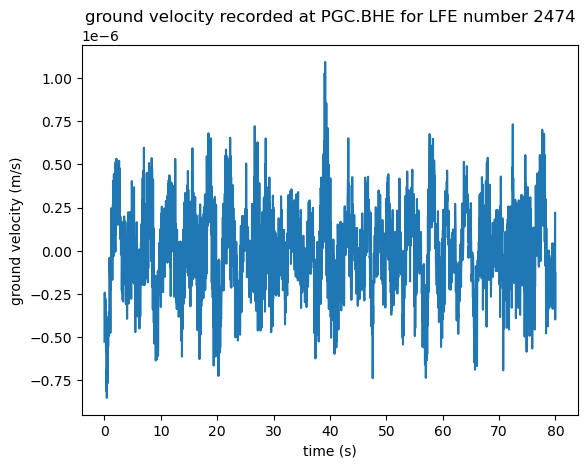

In [6]:
# if we pick one of these station/channels, 
# we can look at the data for a number of recordings at these stations
ky='PGC.BHE'
data=lf.data[ky]

print('Data size for this station/channel: ',data.shape)

# here each column is the record at this station for one LFE
time=np.arange(0,data.shape[0])/lf.sampling_rate
plt.plot(time,data[:,0])
plt.xlabel('time (s)');
plt.ylabel('ground velocity (m/s)');
plt.title('ground velocity recorded at {:s} for LFE number {:d}'.format(ky,lf.ev[ky][0]));

# but not all LFEs are recorded or downloaded at all stations, so 
# lf.ev indexes the events that are recorded
print('Events recorded at {:s}:'.format(ky))
print(lf.ev[ky])

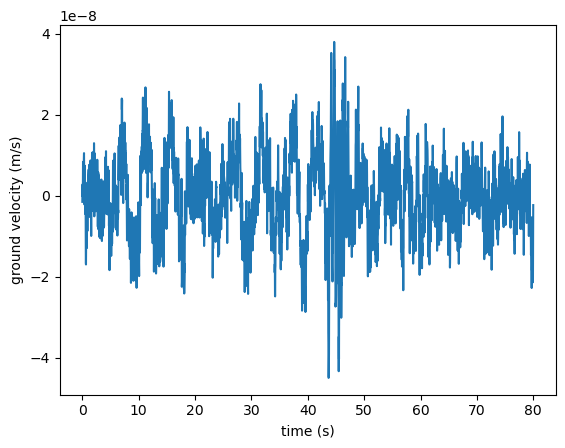

In [7]:
# the data recorded for individual events are *very* noisy
# so later on we'll stack---go ahead and try here to see
plt.plot(time,np.ma.median(data,axis=1));
plt.xlabel('time (s)');
plt.ylabel('ground velocity (m/s)');

### 3. Normalize the data

These data are still pretty noisy, however.  Part of the problem here comes from outliers. A few traces can have locally really big values.  That's why we used the mean instead of the median in the averaging above.

To avoid this, we'll divide each trace by its maximum value.

In [8]:
# normalize the data
lf.normalize_data()

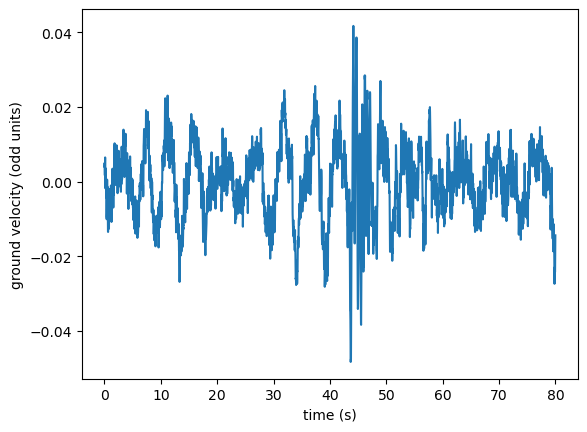

In [9]:
# and try the stack again
plt.plot(time,np.ma.mean(lf.data[ky],axis=1));
plt.xlabel('time (s)');
plt.ylabel('ground velocity (odd units)');

In [10]:
# the normalization removes some of the amplitude information
# but we might want this later, so we've saved it


# data_norm contains what we've divided by
print(lf.data_norm)

# and data_max contains the max value in each trace
# normally that's what we've divided by, but not always
print(lf.data_max)

{'B011': array([1.09440411e-06, 8.84503198e-07, 5.82746238e-07, ...,
       4.63079451e-07, 6.12765237e-07, 5.58291824e-07]), 'B926': array([2.38132755e-07, 2.27622212e-07, 3.06098462e-07, ...,
       4.52192496e-07, 5.99819085e-07, 6.02477919e-07]), 'BPCB': array([], dtype=float64), 'GOWB': array([], dtype=float64), 'KHVB': array([5.41098574e-06, 5.41103704e-06, 2.93068278e-06, 2.51945098e-06,
       2.51912439e-06, 2.51996645e-06, 1.99253918e-06, 1.78706680e-06,
       1.78701987e-06, 1.78707799e-06, 1.78722400e-06, 2.21888266e-06,
       2.21885807e-06, 1.98506448e-06, 2.08859761e-06, 2.20961112e-06,
       3.03627754e-06, 2.88334917e-06, 2.88294580e-06, 2.52172429e-06,
       7.98431938e-07, 7.93330606e-07, 7.47375913e-07, 8.79674701e-07,
       8.61041258e-07, 8.83396311e-07, 8.83568943e-07, 8.83599689e-07,
       9.94078626e-07, 9.94345710e-07, 9.94491955e-07, 8.93813238e-07,
       8.32858928e-07, 8.32791809e-07, 8.32919962e-07, 7.70419641e-07,
       4.84079347e-06, 5.24968191e

### 4. Bandpass filter the data 

Even with the normalization to discard outliers, the stack isn't great.  That's partly because the signal to noise ratio isn't very good at very low or very high frequencies.  So before we do anything else with the data, let's bandpass filter each trace.

In [11]:
# for now, try looking at the 1-10 Hz band
lf.filter_data(flm=[1,10])

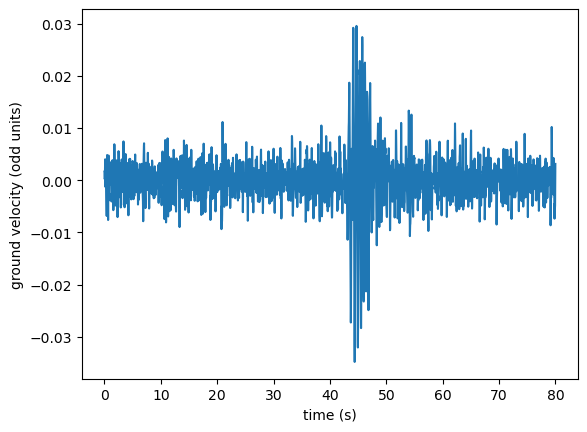

In [12]:
# and try the stack again
plt.plot(time,np.ma.mean(lf.data[ky],axis=1));
plt.xlabel('time (s)');
plt.ylabel('ground velocity (odd units)');

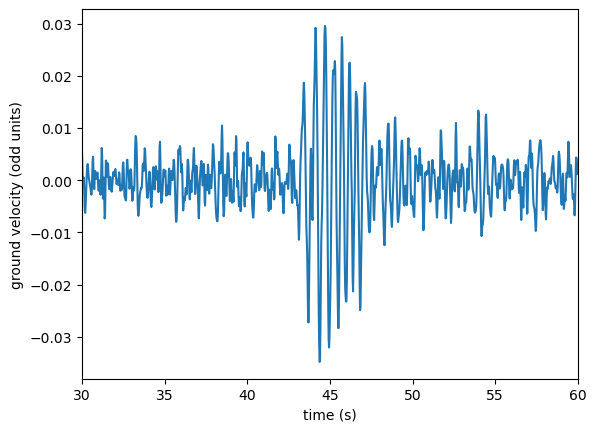

In [13]:
# maybe zoom in
plt.plot(time,np.ma.mean(lf.data[ky],axis=1));
plt.xlim([30,60])
plt.xlabel('time (s)');
plt.ylabel('ground velocity (odd units)');

### 5. Summary

This is a good start.  We'll address some other modifications of the stacks later.  But for now we have 

1. Normalized, filtered data for each station/channel in lf.data
2. The LFEs for each station in lf.ev
3. The normalization and max values for each record in lf.data_norm and lf.data_max